[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/11_time/11_time_practice_quiz.ipynb)

# 11 — Time Series: Practice Quiz

These questions cover the full module: datetime indexing, resampling, rolling windows, period-over-period comparisons, and seasonal groupby patterns. All questions use the same bike-sharing dataset used throughout the module.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_parquet("bike_daily.parquet")
print("Shape:", df.shape)
df.head()

Shape: (731, 11)


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,casual,registered,cnt
dteday,,,,,,,,,,,
2011-01-01,1,0,1,0,6,0,2,0.344167,331,654,985
2011-01-02,1,0,1,0,0,0,2,0.363478,131,670,801
2011-01-03,1,0,1,0,1,1,1,0.196364,120,1229,1349
2011-01-04,1,0,1,0,2,1,1,0.200000,108,1454,1562
2011-01-05,1,0,1,0,3,1,1,0.226957,82,1518,1600


---
### Question 1

What does `pd.to_datetime(df["dteday"])` do that makes time-series operations possible?

A. It sorts the column in chronological order  
B. It converts a column of date strings into a `datetime64` dtype that pandas can do date arithmetic on  
C. It sets the column as the DataFrame index  
D. It removes rows where the date is missing

**Your answer:**

In [2]:
answer = ""

In [3]:
#@title Solution
# Answer: B
# pd.to_datetime() changes the dtype from object (text) to datetime64.
# After the conversion, pandas understands the values as timestamps:
# you can subtract one from another, extract .month or .dayofweek,
# compare with > and <, and use them as a DatetimeIndex.
# Sorting (A) happens separately with sort_index().
# Setting the index (C) happens separately with set_index().
print("Before:", df.index.dtype)
# The parquet already has the DatetimeIndex set:
print("After set_index + to_datetime:", df.index.dtype)

Before: datetime64[us]
After set_index + to_datetime: datetime64[us]


---
### Question 2

Given a DataFrame with a `DatetimeIndex` covering 2011–2012, what does `df.loc["2011-08"]` return?

A. A single row for August 1, 2011  
B. All rows from August 1 through August 31, 2011  
C. All rows from 2011 where month > 8  
D. A `KeyError` because `"2011-08"` is not a valid index label

**Your answer:**

In [4]:
answer = ""

In [5]:
#@title Solution
# Answer: B
# Partial string indexing matches all rows whose timestamp falls within
# the period named by the string. "2011-08" names the month of August 2011,
# so all 31 days are returned. This only works with a DatetimeIndex.
aug_2011 = df.loc["2011-08"]
print("Rows returned:", len(aug_2011))
print("First:", aug_2011.index[0].date(), "Last:", aug_2011.index[-1].date())

Rows returned: 31
First: 2011-08-01 Last: 2011-08-31


---
### Question 3

You want to answer "how many total bike rentals happened each month?" Which call is correct?

A. `df["cnt"].resample("ME").mean()`  
B. `df["cnt"].resample("ME").sum()`  
C. `df["cnt"].resample("ME").count()`  
D. `df["cnt"].resample("ME").max()`

**Your answer:**

In [6]:
answer = ""

In [7]:
#@title Solution
# Answer: B
# cnt is a daily count. To find the total across a month, add up the daily
# counts with .sum(). .mean() gives the average rentals on a typical day
# in that month (a different question). .count() counts non-null rows
# (always 28-31 for a clean dataset). .max() gives the single peak day.
monthly_total = df["cnt"].resample("ME").sum()
print(monthly_total.head())

dteday
2011-01-31     38189
2011-02-28     48215
2011-03-31     64045
2011-04-30     94870
2011-05-31    135821
Freq: ME, Name: cnt, dtype: int64


---
### Question 4

How many `NaN` values appear at the start of `df["cnt"].rolling(7).mean()`?

A. 0 — rolling fills missing windows with partial averages  
B. 1 — only the very first row lacks a previous row  
C. 6 — the first 6 rows do not have 7 days of prior data  
D. 7 — the first 7 rows cannot form a complete window

**Your answer:**

In [8]:
answer = ""

In [9]:
#@title Solution
# Answer: C
# rolling(7) requires 7 values to compute a mean: the current row plus
# the 6 preceding rows. Rows 0–5 have fewer than 6 predecessors, so they
# are NaN. Row 6 (the 7th row) is the first with a full window.
r7 = df["cnt"].rolling(7).mean()
print("First 8 values:")
print(r7.head(8).round(1))
print("NaN count:", r7.isna().sum())

First 8 values:
dteday
2011-01-01       NaN
2011-01-02       NaN
2011-01-03       NaN
2011-01-04       NaN
2011-01-05       NaN
2011-01-06       NaN
2011-01-07    1344.7
2011-01-08    1341.0
Name: cnt, dtype: float64
NaN count: 6


---
### Question 5

What does `.pct_change(12)` compute when called on a monthly Series?

A. The average percent change across a 12-month rolling window  
B. The percent change between each month and the same month 12 periods (one year) earlier  
C. The cumulative percent change over the entire 12-month series  
D. The percent change between each month and the previous month, multiplied by 12

**Your answer:**

In [10]:
answer = ""

In [11]:
#@title Solution
# Answer: B
# pct_change(n) compares each row to the row n positions earlier.
# On monthly data, n=12 means "same month last year," removing the
# seasonal effect and showing pure year-over-year growth.
# The first 12 rows are NaN because 2011 has no year-ago baseline.
monthly = df["cnt"].resample("ME").sum()
yoy = monthly.pct_change(12).dropna()
print("Year-over-year percent change (2012 vs 2011):")
print(yoy.mul(100).round(1).to_string())

Year-over-year percent change (2012 vs 2011):
dteday
2012-01-31    153.3
2012-02-29    113.9
2012-03-31    157.4
2012-04-30     83.6
2012-05-31     44.2
2012-06-30     41.3
2012-07-31     44.1
2012-08-31     56.9
2012-09-30     71.5
2012-10-31     61.0
2012-11-30     49.4
2012-12-31     41.7
Freq: ME


---
### Question 6

What value does `df.index.dayofweek` return for a Monday?

A. 0  
B. 1  
C. 6  
D. 7

**Your answer:**

In [12]:
answer = ""

In [13]:
#@title Solution
# Answer: A
# dayofweek uses 0=Monday through 6=Sunday (ISO convention).
# Confirm: January 3, 2011 was a Monday.
print(df.index[2].day_name(), "-> dayofweek =", df.index[2].dayofweek)

for i, name in enumerate(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]):
    print(f"  {name}: {i}")

Monday -> dayofweek = 0
  Mon: 0
  Tue: 1
  Wed: 2
  Thu: 3
  Fri: 4
  Sat: 5
  Sun: 6


---
### Question 7

What is the key difference between resampling and a rolling window?

A. Resampling requires a DatetimeIndex; rolling windows do not  
B. Resampling reduces the number of rows by collapsing each period to one value; a rolling window keeps the same number of rows and overlays a smoothed value on top of each original row  
C. Rolling windows can only compute means; resampling supports any aggregation  
D. Resampling can only be applied to a single column; rolling windows work on whole DataFrames

**Your answer:**

In [14]:
answer = ""

In [15]:
#@title Solution
# Answer: B
# Resampling changes the granularity of the data: 731 daily rows become
# 24 monthly rows. The original daily index is gone.
# Rolling windows preserve the original index: the smoothed series still
# has 731 rows and can be plotted alongside the raw data.
# (A) Both require a DatetimeIndex for meaningful use.
# (C) Rolling supports .std(), .sum(), .min(), .max(), etc.
# (D) Both can be applied to the whole DataFrame.
print("Daily rows:", len(df))
print("After resample(ME).sum():", len(df["cnt"].resample("ME").sum()))
print("After rolling(7).mean():", len(df["cnt"].rolling(7).mean()))

Daily rows: 731
After resample(ME).sum(): 24
After rolling(7).mean(): 731


---
### Question 8

Use partial string indexing to select all rows from **the second half of 2012** (July through December). Print the shape of the result and the total rental count for that period.

In [16]:
# your code here

In [17]:
#@title Solution
h2_2012 = df.loc["2012-07":"2012-12"]
print("Shape:", h2_2012.shape)
print("Total rentals:", h2_2012["cnt"].sum())

Shape: (184, 11)
Total rentals: 1111901


---
### Question 9

Compute the **monthly mean** daily rental count using `.resample("ME").mean()`. Plot the result as a bar chart with the title "Monthly mean daily rentals" and rotated x-axis labels showing month and year (e.g., "Jan 2011").

In [18]:
# your code here

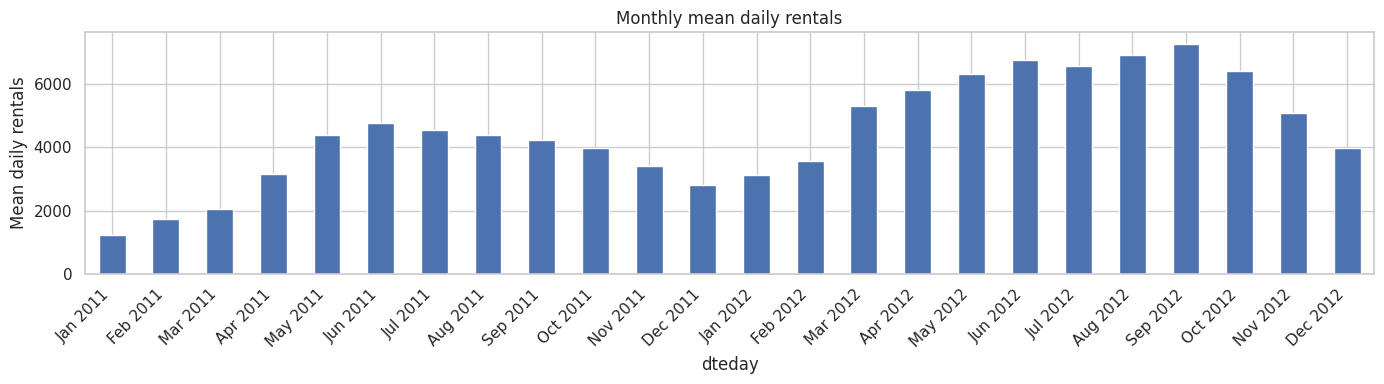

In [19]:
#@title Solution
monthly_mean = df["cnt"].resample("ME").mean().round(1)
ax = monthly_mean.plot(kind="bar", figsize=(14, 4),
                       title="Monthly mean daily rentals")
ax.set_ylabel("Mean daily rentals")
ax.set_xticklabels([d.strftime("%b %Y") for d in monthly_mean.index],
                   rotation=45, ha="right")
plt.tight_layout()

---
### Question 10

Compute a **14-day rolling mean** of `cnt`. Plot it overlaid on the raw daily series on the same axes. Use `alpha=0.35` for the raw series and `linewidth=2` for the rolling mean. Add a legend and a descriptive title.

In [20]:
# your code here

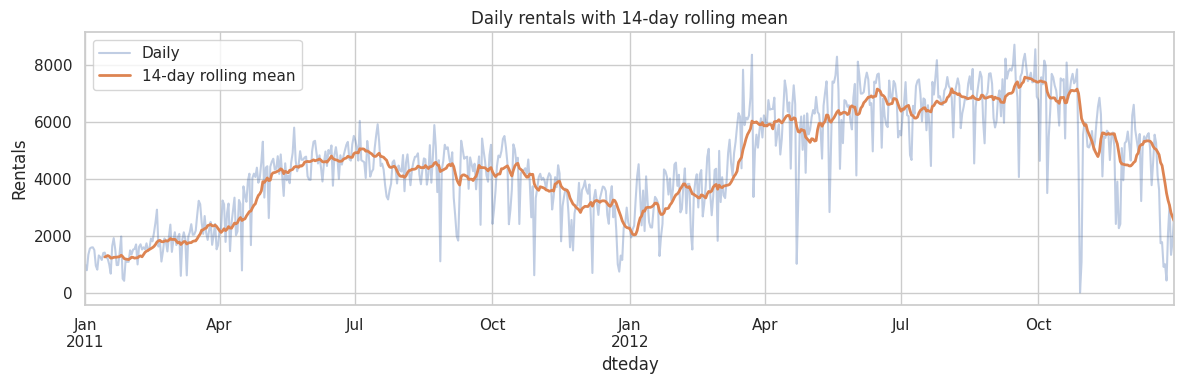

In [21]:
#@title Solution
fig, ax = plt.subplots(figsize=(12, 4))
df["cnt"].plot(ax=ax, alpha=0.35, label="Daily")
df["cnt"].rolling(14).mean().plot(ax=ax, linewidth=2, label="14-day rolling mean")
ax.set_title("Daily rentals with 14-day rolling mean")
ax.set_ylabel("Rentals")
ax.legend()
plt.tight_layout()

---
### Question 11

Use `.diff()` and `.idxmax()` to find the date and value of the **single largest one-day gain** in total rentals. Print the date (as a plain date, not a timestamp) and the gain value as an integer.

In [22]:
# your code here

In [23]:
#@title Solution
daily_diff = df["cnt"].diff()
print("Largest one-day gain:")
print(" Date: ", daily_diff.idxmax().date())
print(" Gain: ", int(daily_diff.max()))

Largest one-day gain:
 Date:  2012-10-31
 Gain:  4470


---
### Question 12

Use `groupby` on `df.index.month` to compute the average `cnt` per month (averaging across both years). Relabel the index with short month names (Jan, Feb, ...) and plot as a bar chart. Which month has the highest average, and which has the lowest? Use `.idxmax()` and `.idxmin()` to find the answers.

In [24]:
# your code here

Highest: Jun -> 5772.0
Lowest:  Jan -> 2176.0


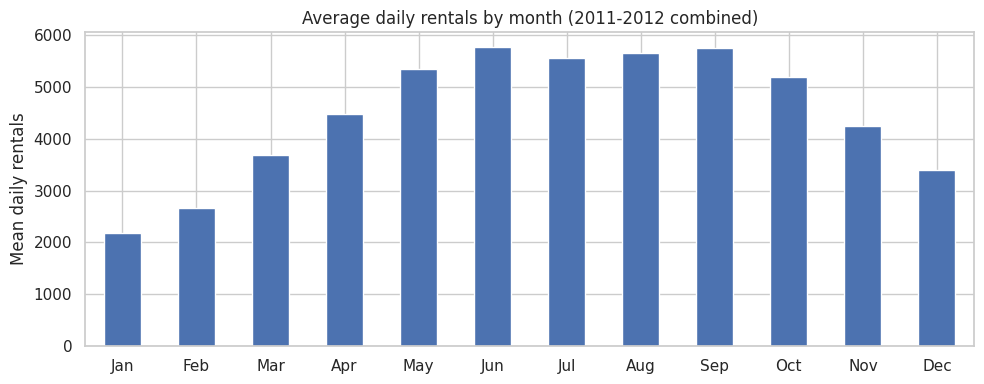

In [25]:
#@title Solution
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
by_month = df.groupby(df.index.month)["cnt"].mean().round(0)
by_month.index = month_labels

ax = by_month.plot(kind="bar", figsize=(10, 4),
                   title="Average daily rentals by month (2011-2012 combined)")
ax.set_ylabel("Mean daily rentals")
ax.set_xticklabels(month_labels, rotation=0)
plt.tight_layout()

print("Highest:", by_month.idxmax(), "->", by_month.max())
print("Lowest: ", by_month.idxmin(), "->", by_month.min())